# One-Stage vs Two-Stage (Severstal)

## Current Status
This notebook belongs to the **one-stage vs two-stage** track.

At this stage, we are mainly using it to keep the comparison pipeline stable while one-stage method exploration is still ongoing.

## Caveat
- One-stage method selection is still exploratory and being refined in a separate notebook.
- Two-stage experiments are also maintained separately.
- So outputs here should be treated as comparison checkpoint results, not final locked results.

## Evaluation setup
Three-way evaluation labels:
- `normal` (non-defect)
- `known defect`
- `unknown defect`


In [7]:
# Cell 1: Repo setup (fresh runtime safe)
import os, subprocess, sys
from pathlib import Path

REPO_URL = "https://github.com/spinelessknave8/FYP_code.git"
REPO_DIR = Path("/content/FYP-code")

if not REPO_DIR.exists():
    subprocess.check_call(["git", "clone", REPO_URL, str(REPO_DIR)])
else:
    subprocess.check_call(["git", "-C", str(REPO_DIR), "pull", "--ff-only"])

os.chdir(REPO_DIR)
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

print("cwd:", Path.cwd())


cwd: /content/FYP-code


In [8]:
# Cell 2: Mount Drive + generate Colab configs
from google.colab import drive
from pathlib import Path
import yaml


drive.mount('/content/drive')

sev = Path('/content/drive/MyDrive/datasets/severstal')
assert sev.exists(), f"Missing {sev}"
assert (sev / 'train.csv').exists(), "Missing train.csv"
assert (sev / 'train_images').exists(), "Missing train_images"

base_path = Path('severstral-osr/configs/default.yaml')
base_cfg = yaml.safe_load(base_path.read_text())
base_cfg['device'] = 'cuda'
base_cfg['num_workers'] = 2
base_cfg['severstal']['data_root'] = str(sev)
base_cfg['severstal']['train_csv'] = 'train.csv'
base_cfg['severstal']['images_dir'] = 'train_images'
base_cfg['output_dir'] = '/content/drive/MyDrive/fyp_outputs/severstral_osr'

Path('severstral-osr/configs/default.colab.yaml').write_text(yaml.safe_dump(base_cfg, sort_keys=False))

for s in ['a', 'b', 'c', 'd']:
    split_cfg = yaml.safe_load(Path(f'severstral-osr/configs/split_{s}.yaml').read_text())
    merged = yaml.safe_load(yaml.safe_dump(base_cfg))
    merged.update(split_cfg)
    Path(f'severstral-osr/configs/split_{s}.colab.yaml').write_text(yaml.safe_dump(merged, sort_keys=False))

print('Wrote Colab configs for splits a,b,c,d')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Wrote Colab configs for splits a,b,c,d


In [ ]:
# Cell 2.5: OPTIONAL hard reset outputs (recommended when logic changed)
# Set HARD_RESET=True to delete old cached results and force a clean rerun.
import shutil
from pathlib import Path

HARD_RESET = True
OUT = Path('/content/drive/MyDrive/fyp_outputs/severstral_osr')

if HARD_RESET and OUT.exists():
    shutil.rmtree(OUT)
    print('Deleted:', OUT)
else:
    print('No deletion. HARD_RESET=', HARD_RESET, 'exists=', OUT.exists())


In [9]:
# Cell 3: Run stage-1 once (PatchCore normal model, checkpoint-aware)
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path('severstral-osr/src').resolve()))
from notebook_entrypoints import run_stage1

run_stage1('severstral-osr/configs/default.colab.yaml')


[severstal-osr] stage1 skip (found cached outputs): /content/drive/MyDrive/fyp_outputs/severstral_osr/patchcore


In [ ]:
# Cell 4: Run all splits (one-stage + two-stage)
# FORCE_RERUN=True will ignore existing per-split outputs.
import sys
from pathlib import Path

FORCE_RERUN = True

sys.path.insert(0, str(Path('severstral-osr/src').resolve()))
from notebook_entrypoints import run_split_pipeline

for s in ['a', 'b', 'c', 'd']:
    cfg = f'severstral-osr/configs/split_{s}.colab.yaml'
    print(f"\n=== Running {cfg} ===")
    run_split_pipeline(cfg, skip_if_complete=(not FORCE_RERUN))


In [11]:
# Cell 5: Aggregate one-stage (OSR) + two-stage (Cascade) metrics
import json
from pathlib import Path
import pandas as pd

OUT = Path('/content/drive/MyDrive/fyp_outputs/severstral_osr')
rows = []

for s in ['a', 'b', 'c', 'd']:
    split = f'split_{s}'
    osr_p = OUT / split / 'osr' / 'metrics.json'
    cas_p = OUT / split / 'cascade' / 'metrics.json'
    row = {'split': split}

    if osr_p.exists():
        m = json.loads(osr_p.read_text())
        row.update({
            'one_auroc_known_unknown': m.get('auroc_known_unknown'),
            'one_tpr_unknown': m.get('tpr_unknown'),
            'one_fpr_known': m.get('fpr_known'),
            'one_open_set_acc': m.get('open_set_acc'),
            'one_known_acc': m.get('known_accuracy'),
            'one_tau': m.get('tau'),
            'one_kappa': m.get('kappa'),
        })

    if cas_p.exists():
        c = json.loads(cas_p.read_text())
        row.update({
            'two_tpr_unknown_system': c.get('tpr_unknown_system'),
            'two_fpr_known_system': c.get('fpr_known_system'),
            'two_pass_known': c.get('stage1_pass_rate_known'),
            'two_pass_unknown': c.get('stage1_pass_rate_unknown'),
            'two_tau': c.get('patchcore_threshold'),
            'two_kappa': c.get('kappa'),
            'two_fusion_rule': c.get('fusion_rule'),
        })

    rows.append(row)

df = pd.DataFrame(rows)
display(df)

mean_row = df.mean(numeric_only=True).to_frame().T
mean_row.index = ['mean']
display(mean_row)

out_csv = OUT / 'one_stage_vs_two_stage_summary.csv'
df.to_csv(out_csv, index=False)
print('Wrote:', out_csv)


,split,one_auroc_known_unknown,one_tpr_unknown,one_fpr_known,one_open_set_acc,one_known_acc,one_tau,one_kappa,two_tpr_unknown_system,two_fpr_known_system,two_pass_known,two_pass_unknown,two_tau,two_kappa,two_fusion_rule
0,split_a,0.611167,0.058140,0.095238,0.587509,0.939605,1031.975481,0.615592,0.046512,0.077816,0.563298,0.839147,2.933017,0.9,and
1,split_b,0.588827,0.238495,0.138393,0.266506,0.825893,4247.821363,0.609088,0.176718,0.133929,0.571429,0.591301,2.938982,0.9,and
2,split_c,0.425889,0.292308,0.094609,0.797101,0.898790,977.019060,0.709140,0.215385,0.075908,0.558856,0.441026,2.964586,0.9,and
3,split_d,0.224614,0.236671,0.091130,0.584171,0.940462,1641.653157,0.748313,0.165150,0.092345,0.535844,0.335501,3.014245,0.9,and


,one_auroc_known_unknown,one_tpr_unknown,one_fpr_known,one_open_set_acc,one_known_acc,one_tau,one_kappa,two_tpr_unknown_system,two_fpr_known_system,two_pass_known,two_pass_unknown,two_tau,two_kappa
mean,0.462624,0.206403,0.104843,0.558822,0.901187,1974.617265,0.670533,0.150941,0.094999,0.557357,0.551744,2.962708,0.9


Wrote: /content/drive/MyDrive/fyp_outputs/severstral_osr/one_stage_vs_two_stage_summary.csv


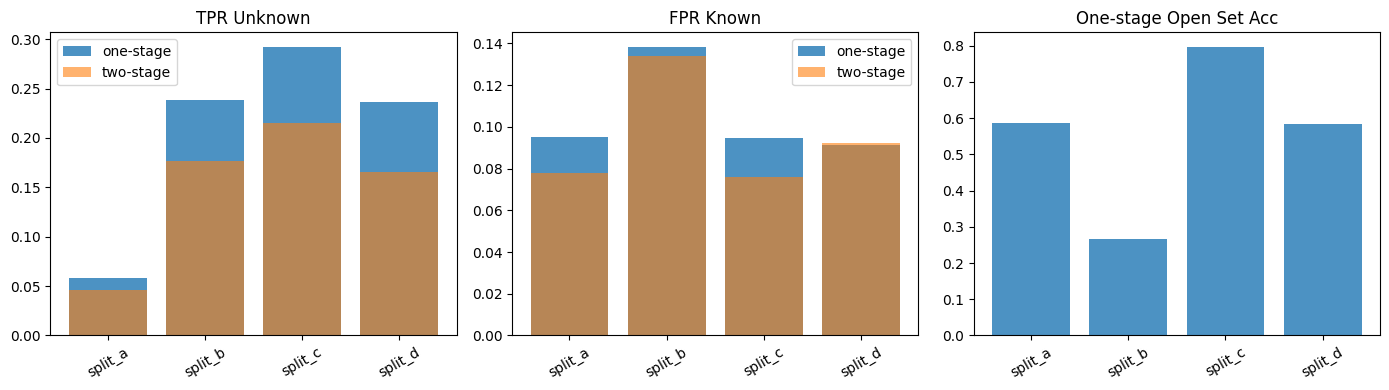

Wrote: /content/drive/MyDrive/fyp_outputs/severstral_osr/one_stage_vs_two_stage_quick_plot.png


In [12]:
# Cell 6: Quick comparison plots
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path('/content/drive/MyDrive/fyp_outputs/severstral_osr')
df = pd.read_csv(OUT / 'one_stage_vs_two_stage_summary.csv')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

x = range(len(df))
labels = df['split'].tolist()

axes[0].bar(x, df['one_tpr_unknown'], alpha=0.8, label='one-stage')
axes[0].bar(x, df['two_tpr_unknown_system'], alpha=0.6, label='two-stage')
axes[0].set_title('TPR Unknown')
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(labels, rotation=30)
axes[0].legend()

axes[1].bar(x, df['one_fpr_known'], alpha=0.8, label='one-stage')
axes[1].bar(x, df['two_fpr_known_system'], alpha=0.6, label='two-stage')
axes[1].set_title('FPR Known')
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(labels, rotation=30)
axes[1].legend()

axes[2].bar(x, df['one_open_set_acc'], alpha=0.8, label='one-stage')
axes[2].set_title('One-stage Open Set Acc')
axes[2].set_xticks(list(x)); axes[2].set_xticklabels(labels, rotation=30)

plt.tight_layout()
plot_path = OUT / 'one_stage_vs_two_stage_quick_plot.png'
plt.savefig(plot_path, dpi=160)
plt.show()
print('Wrote:', plot_path)


## Notes
- `HARD_RESET=True` deletes old outputs so results are fully clean.
- `FORCE_RERUN=True` recomputes splits even if outputs exist.
- One-stage methodology definition is locked in `notes.md`.
